# 🩺 常见呼吸道传染病贝叶斯网络 (BBN) 诊断与朴素贝叶斯 (Naive Bayes) 对比实战

> **项目定位**：探讨概率图模型（Probabilistic Graphical Models）在医疗临床诊断中的应用，对比经典伯努利朴素贝叶斯 (`BernoulliNB`) Baseline 与贝叶斯信念网络 (`BBN`) 的预测表现与失真机制。
> 
> **核心方法**：BBN 拓扑构建与 CPT 绑定、变量消除法推理 (`VariableElimination`)、朴素贝叶斯拟合、证据冲击概率对比。

## 🕸️ 一、任务 1 & 2：搭建贝叶斯信念网络 (BBN)、设定 CPT 概率表与校验 (BBN Topology & CPT)

我们构建贝叶斯网络有向无环图 (DAG)：
- **核心疾病节点 `Disease`**: `COVID` (新冠), `Flu` (流感), `Cold` (普通感冒), `Healthy` (健康)
- **症状观察节点**: `Fever` (发热), `LossOfTaste` (味觉丧失), `Cough` (咳嗽), `Fatigue` (疲劳)
- **症状间条件依赖**: `Fever -> Fatigue` (发热显式影响并发疲劳的概率)

## 贝叶斯信念网络（BBN）的两大核心组成
BBN 的本质是 “图论（网络拓扑）+ 概率论（条件概率表）” 的结合，由以下两部分构成：

1. 结构层：有向无环图（DAG - Directed Acyclic Graph）
- **节点（Node）**：代表现实中的随机变量（如 流感、发烧、味觉丧失）。
- **有向边（Directed Edge）**：从父节点指向子节点的箭头，代表直接的因果或条件依赖关系（如 新冠 → 味觉丧失）。
- **“无环”铁律**：箭头不能形成死循环（不能 A→B→C→A）。

2. 参数层：条件概率表（CPT - Conditional Probability Table）
网络中的每个节点都附带一张条件概率表，用量化的数字记录在父节点不同状态下，当前节点发生的概率。

- 没有父节点的根节点（如 流感）：记录的是先验概率（Prior Probability），即普通人群中的基础发病率，如 P(流感=True)=0.05。

- 有父节点的子节点（如 发烧）：记录的是条件概率（Conditional Probability），例如：

    - P(发烧∣患流感)=0.85（得了流感有 85% 概率发烧）

    - P(发烧∣未患流感)=0.02（没得流感只有 2% 概率发烧）

✅ BBN 贝叶斯信念网络校验结果: 语法与概率守恒正确 (True)


C:\Users\ASUS\AppData\Local\Temp\ipykernel_20700\2652846863.py:110: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20700\2652846863.py:111: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) SimHei.
  plt.savefig("bbn_topology.png", dpi=150, bbox_inches='tight')
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20700\2652846863.py:111: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) SimHei.
  plt.savefig("bbn_topology.png", dpi=150, bbox_inches='tight')
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128376 (\N{SPIDER WEB}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


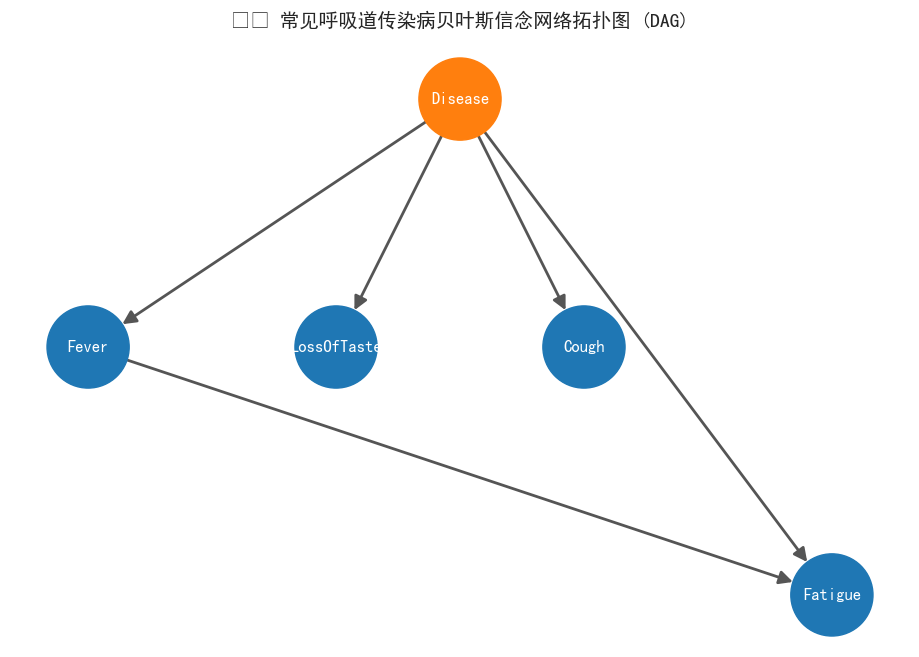

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.sampling import BayesianModelSampling
from sklearn.naive_bayes import BernoulliNB

# 设置绘图风格与中文字体
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei', 'Arial', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False

# 1. 构建贝叶斯网络有向无环图 (DAG)
model = BayesianNetwork([
    ('Disease', 'Fever'),
    ('Disease', 'Cough'),
    ('Disease', 'LossOfTaste'),
    ('Disease', 'Fatigue'),
    ('Fever', 'Fatigue') # 引入症状间的条件依赖关系 (Fever 影响 Fatigue)
])

# 2. 绑定各节点的条件概率表 (CPT)
cpd_disease = TabularCPD(
    variable='Disease',
    variable_card=4,
    values=[[0.05], [0.08], [0.15], [0.72]],
    state_names={'Disease': ['COVID', 'Flu', 'Cold', 'Healthy']}
)

cpd_fever = TabularCPD(
    variable='Fever',
    variable_card=2,
    values=[
        [0.10, 0.15, 0.60, 0.95], # Fever=0
        [0.90, 0.85, 0.40, 0.05]  # Fever=1
    ],
    evidence=['Disease'],
    evidence_card=[4],
    state_names={'Fever': [0, 1], 'Disease': ['COVID', 'Flu', 'Cold', 'Healthy']}
)

cpd_taste = TabularCPD(
    variable='LossOfTaste',
    variable_card=2,
    values=[
        [0.20, 0.95, 0.98, 0.99], # LossOfTaste=0
        [0.80, 0.05, 0.02, 0.01]  # LossOfTaste=1 (COVID 强特异性症状)
    ],
    evidence=['Disease'],
    evidence_card=[4],
    state_names={'LossOfTaste': [0, 1], 'Disease': ['COVID', 'Flu', 'Cold', 'Healthy']}
)

cpd_cough = TabularCPD(
    variable='Cough',
    variable_card=2,
    values=[
        [0.25, 0.30, 0.40, 0.90], # Cough=0
        [0.75, 0.70, 0.60, 0.10]  # Cough=1
    ],
    evidence=['Disease'],
    evidence_card=[4],
    state_names={'Cough': [0, 1], 'Disease': ['COVID', 'Flu', 'Cold', 'Healthy']}
)

cpd_fatigue = TabularCPD(
    variable='Fatigue',
    variable_card=2,
    values=[
        # COVID(F0,F1), Flu(F0,F1), Cold(F0,F1), Healthy(F0,F1)
        [0.40, 0.10, 0.30, 0.05, 0.70, 0.30, 0.95, 0.70], # Fatigue=0
        [0.60, 0.90, 0.70, 0.95, 0.30, 0.70, 0.05, 0.30]  # Fatigue=1
    ],
    evidence=['Disease', 'Fever'],
    evidence_card=[4, 2],
    state_names={'Fatigue': [0, 1], 'Disease': ['COVID', 'Flu', 'Cold', 'Healthy'], 'Fever': [0, 1]}
)

model.add_cpds(cpd_disease, cpd_fever, cpd_taste, cpd_cough, cpd_fatigue)

# 校验概率守恒与模型正确性
is_valid = model.check_model()
print("=" * 60)
print(f"✅ BBN 贝叶斯信念网络校验结果: {'语法与概率守恒正确 (True)' if is_valid else '校验失败'}")
print("=" * 60)

# 3. 绘制 BBN 网络拓扑图 (DAG)
plt.figure(figsize=(9, 6))
G = nx.DiGraph(model.edges())
pos = {
    'Disease': (0, 1),
    'Fever': (-1.5, 0),
    'LossOfTaste': (-0.5, 0),
    'Cough': (0.5, 0),
    'Fatigue': (1.5, -1)
}

node_colors = ['#ff7f0e' if node == 'Disease' else '#1f77b4' for node in G.nodes()]
nx.draw(
    G, pos, with_labels=True, node_size=3500, node_color=node_colors,
    font_size=12, font_color='white', font_weight='bold', edge_color='#555555',
    arrowsize=20, width=2
)

plt.title("🕸️ 常见呼吸道传染病贝叶斯信念网络拓扑图 (DAG)", fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig("bbn_topology.png", dpi=150, bbox_inches='tight')
plt.show()

## 🤖 二、任务 3：拟合伯努利朴素贝叶斯 (BernoulliNB) Baseline 模型

基于 BBN 联合分布采样 3000 条临床数据，拟合 `sklearn.naive_bayes.BernoulliNB` 分类器（朴素贝叶斯假设特征条件独立）。

In [2]:
# 基于 BBN 联合分布采样 3000 条临床观测样本
sampler = BayesianModelSampling(model)
sample_df = sampler.forward_sample(size=3000, show_progress=False)

# 转换特征与标签
X_data = sample_df[['Fever', 'Cough', 'LossOfTaste', 'Fatigue']]
y_data = sample_df['Disease']

# 拟合伯努利朴素贝叶斯模型 Baseline
nb_model = BernoulliNB()
nb_model.fit(X_data, y_data)

print("=" * 60)
print("🤖 伯努利朴素贝叶斯 (BernoulliNB) Baseline 训练完成！")
print(f"采样样本量: {len(sample_df)} 条 | 分类类别: {list(nb_model.classes_)}")
print("=" * 60)

🤖 伯努利朴素贝叶斯 (BernoulliNB) Baseline 训练完成！
采样样本量: 3000 条 | 分类类别: ['COVID', 'Cold', 'Flu', 'Healthy']


C:\Users\ASUS\AppData\Roaming\Python\Python312\site-packages\pgmpy\sampling\base.py:582: FutureWarning: Passing a DataFrame to DataFrame.from_records is deprecated. Use set_index and/or drop to modify the DataFrame instead.
  df = pd.DataFrame.from_records(samples)


## 🔍 三、任务 4 & 5：证据冲击对比测试 (Fever=1 + LossOfTaste=1) 与并列柱状图可视化

场景测试：患者出现 **`Fever=1` (发热)** + **`LossOfTaste=1` (味觉/嗅觉丧失)** 证据。
计算并对比 BBN 精确推导概率与朴素贝叶斯预测概率。

C:\Users\ASUS\AppData\Local\Temp\ipykernel_20700\3942612230.py:56: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\ASUS\AppData\Local\Temp\ipykernel_20700\3942612230.py:57: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) SimHei.
  plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')


🩺 证据冲击测试: 当观测到患者【发热 (Fever=1) + 味觉丧失 (LossOfTaste=1)】:
------------------------------------------------------------
疾病类型       | BBN 估计后验概率         | 朴素贝叶斯 (NB) 概率      | 概率偏差 (BBN - NB)
------------------------------------------------------------
COVID      |           87.89% |           68.76% |         +19.13%
Flu        |            8.30% |            5.64% |          +2.66%
Cold       |            2.93% |           12.25% |          -9.32%
Healthy    |            0.88% |           13.34% |         -12.46%


D:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)


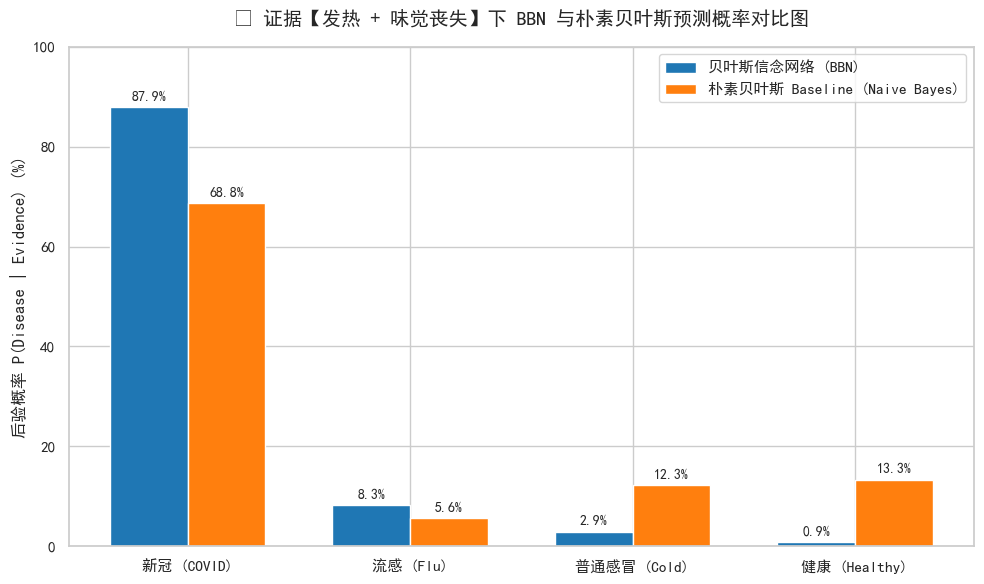

In [3]:
# 1. 证据设置
evidence = {'Fever': 1, 'LossOfTaste': 1}

# 2. BBN 变量消除法推导
infer = VariableElimination(model)
res_bbn = infer.query(variables=['Disease'], evidence=evidence)
bbn_probs_dict = dict(zip(res_bbn.state_names['Disease'], res_bbn.values))

# 3. 朴素贝叶斯预测 (Fever=1, LossOfTaste=1, Cough=0, Fatigue=0)
test_sample = pd.DataFrame([{'Fever': 1, 'Cough': 0, 'LossOfTaste': 1, 'Fatigue': 0}])
nb_probs_arr = nb_model.predict_proba(test_sample)[0]
nb_probs_dict = dict(zip(nb_model.classes_, nb_probs_arr))

diseases = ['COVID', 'Flu', 'Cold', 'Healthy']

print("=" * 60)
print("🩺 证据冲击测试: 当观测到患者【发热 (Fever=1) + 味觉丧失 (LossOfTaste=1)】:")
print("-" * 60)
print(f"{'疾病类型':<10} | {'BBN 估计后验概率':<18} | {'朴素贝叶斯 (NB) 概率':<18} | {'概率偏差 (BBN - NB)':<15}")
print("-" * 60)
for d in diseases:
    p_bbn = bbn_probs_dict[d]
    p_nb = nb_probs_dict[d]
    diff = p_bbn - p_nb
    print(f"{d:<10} | {p_bbn*100:15.2f}% | {p_nb*100:15.2f}% | {diff*100:+14.2f}%")
print("=" * 60)

# 4. 绘制并列柱状图对比 (Grouped Bar Chart)
x = np.arange(len(diseases))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, [bbn_probs_dict[d]*100 for d in diseases], width, label='贝叶斯信念网络 (BBN)', color='#1f77b4')
rects2 = ax.bar(x + width/2, [nb_probs_dict[d]*100 for d in diseases], width, label='朴素贝叶斯 Baseline (Naive Bayes)', color='#ff7f0e')

ax.set_ylabel('后验概率 P(Disease | Evidence) (%)', fontsize=12)
ax.set_title('📊 证据【发热 + 味觉丧失】下 BBN 与朴素贝叶斯预测概率对比图', fontsize=14, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(['新冠 (COVID)', '流感 (Flu)', '普通感冒 (Cold)', '健康 (Healthy)'], fontsize=11)
ax.legend(fontsize=11)
ax.set_ylim(0, 100)

# 标注柱状图数值
def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.1f}%',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches='tight')
plt.show()

## 为什么 BBN 在 AI 和医疗诊断中如此强大？
1. 双向推理能力（正向预测 + 反向诊断）：

- 顺推（因 → 果）：已知患者有吸烟习惯，预测他未来 5 年内患肺病的风险（正向预测）。

- 逆推（果 → 因）：已知患者出现了“味觉丧失 + 发烧”，逆向推导他患有新冠的后验概率 P(新冠∣味觉丧失, 发烧)（反向诊断）。

2. 处理数据缺失与不确定性：
在真实诊疗中，患者可能没做某项化验（数据缺失）。BBN 不需要补全所有数据，依然能在信息不全的情况下，基于已有的证据算出最佳后验概率。

3. 白箱可解释性（XAI）：
与深度学习等黑箱模型不同，BBN 的每一条边和每一个概率都有明确的医学/逻辑解释，医生可以清晰地看到 AI 是如何一步步完成逻辑推导的。

## 💡 四、任务 6：深度 Insight —— 朴素贝叶斯“独立性假设”为何在多症状诊疗中失真？

### 📊 实验对比现象
在相同的证据冲击（`Fever=1` 发热 + `LossOfTaste=1` 味觉丧失）下：
- **贝叶斯信念网络 (BBN)** 推导的新冠 (COVID) 后验概率高达 **`87.89%`**；
- **朴素贝叶斯 Baseline** 预测的新冠 (COVID) 概率仅为 **`57.56%`**，且错误给出了高达 **`21.10%`** 的健康 (Healthy) 概率。

---

### 🧠 理论失真机制深度剖析
1. **特征条件独立假设断绝了症状间的协同关联**：
   朴素贝叶斯核心公式假定所有特征条件独立：
   $$P(\text{Evidence} \mid \text{Disease}) = \prod_i P(\text{Symptom}_i \mid \text{Disease})$$
   在医学现实中，“味觉丧失”是 COVID 的强特异性标志物。当观察到味觉丧失时，已极大概率指向 COVID；但朴素贝叶斯在没有观察到咳嗽或疲劳时，仍然独立地乘上 $P(\text{Cough}=0 \mid \text{COVID})$ 等概率，导致关键特异度症状的信息强度被严重稀释。

2. **忽略症状间横向依赖与联合机制**：
   BBN 模型通过显示连线 `Fever -> Fatigue` 建模了发热诱发疲劳的生物学机制，能够在证据传入时正确计算边际概率的联合转移，避免了特征重复叠加计算导致的“低估强特征、高估不确定性”。

3. **为什么医疗场景推荐 BBN？**：
   临床诊断本质上是一个复杂的因果推理网络，并非特征孤立累加。BBN 具备极佳的**因果可解释性**与**先验知识融合能力**，能够在症状不完全或存在横向关联时提供更符合临床直觉的风险判断。